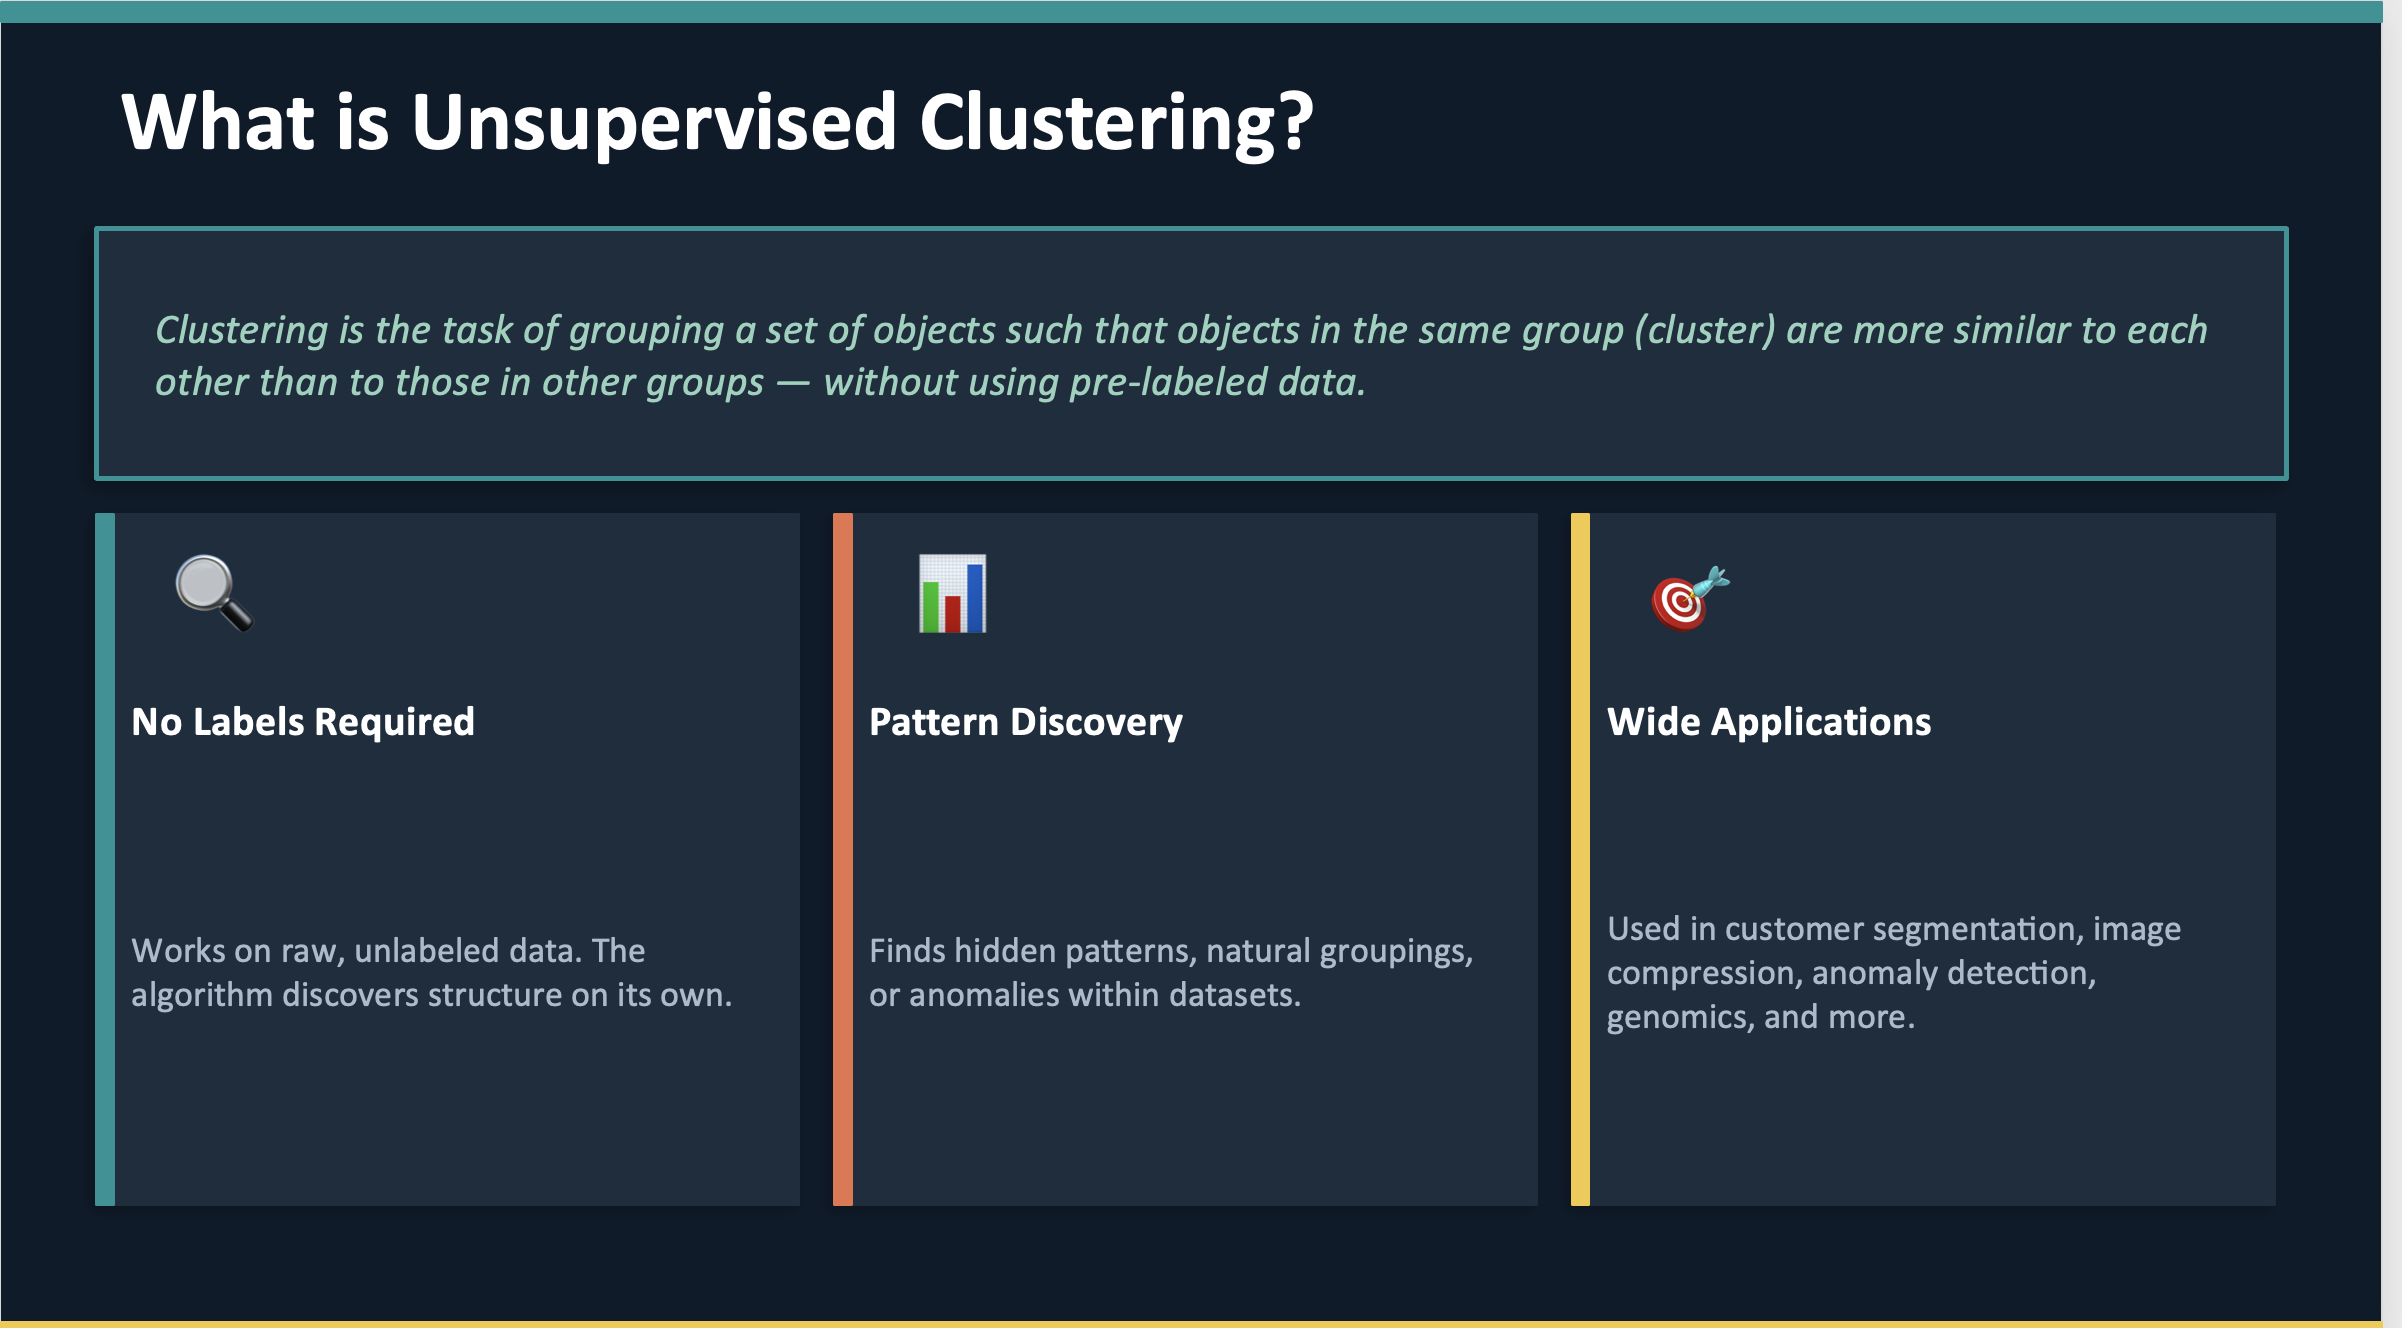

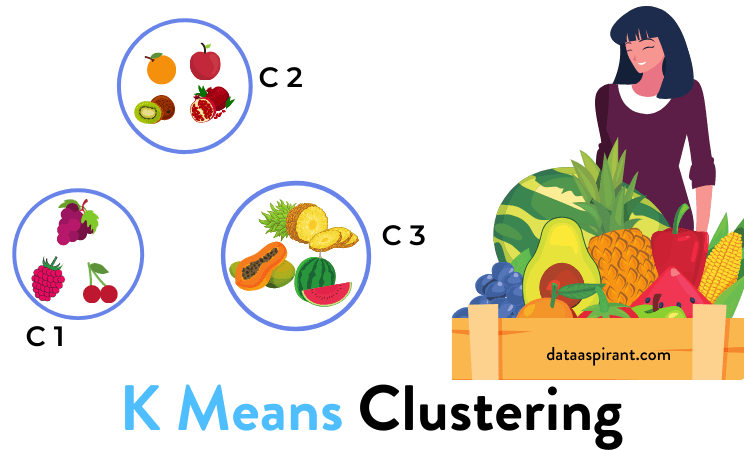

**K-Means** Clustering is an unsupervised machine learning algorithm used to group similar data points into K clusters.


**“K” = number of clusters \
“Means” = average (centroid of cluster)**

It finds patterns in data without labels

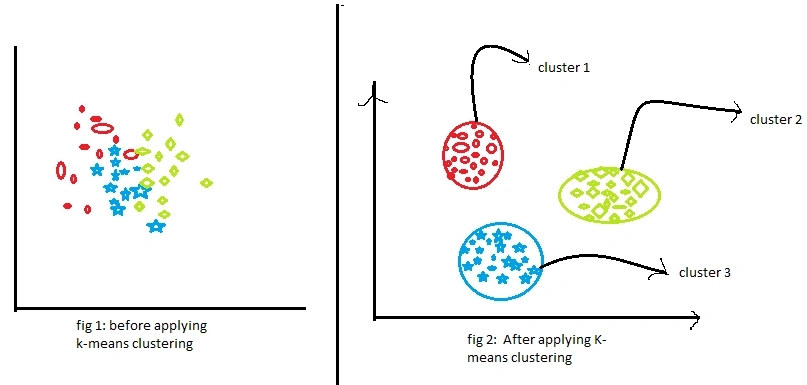

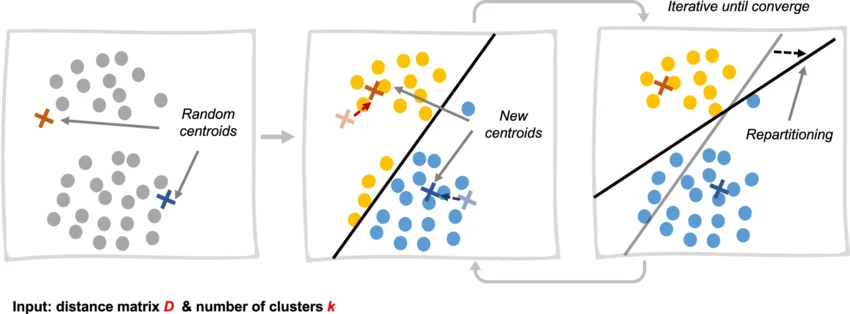

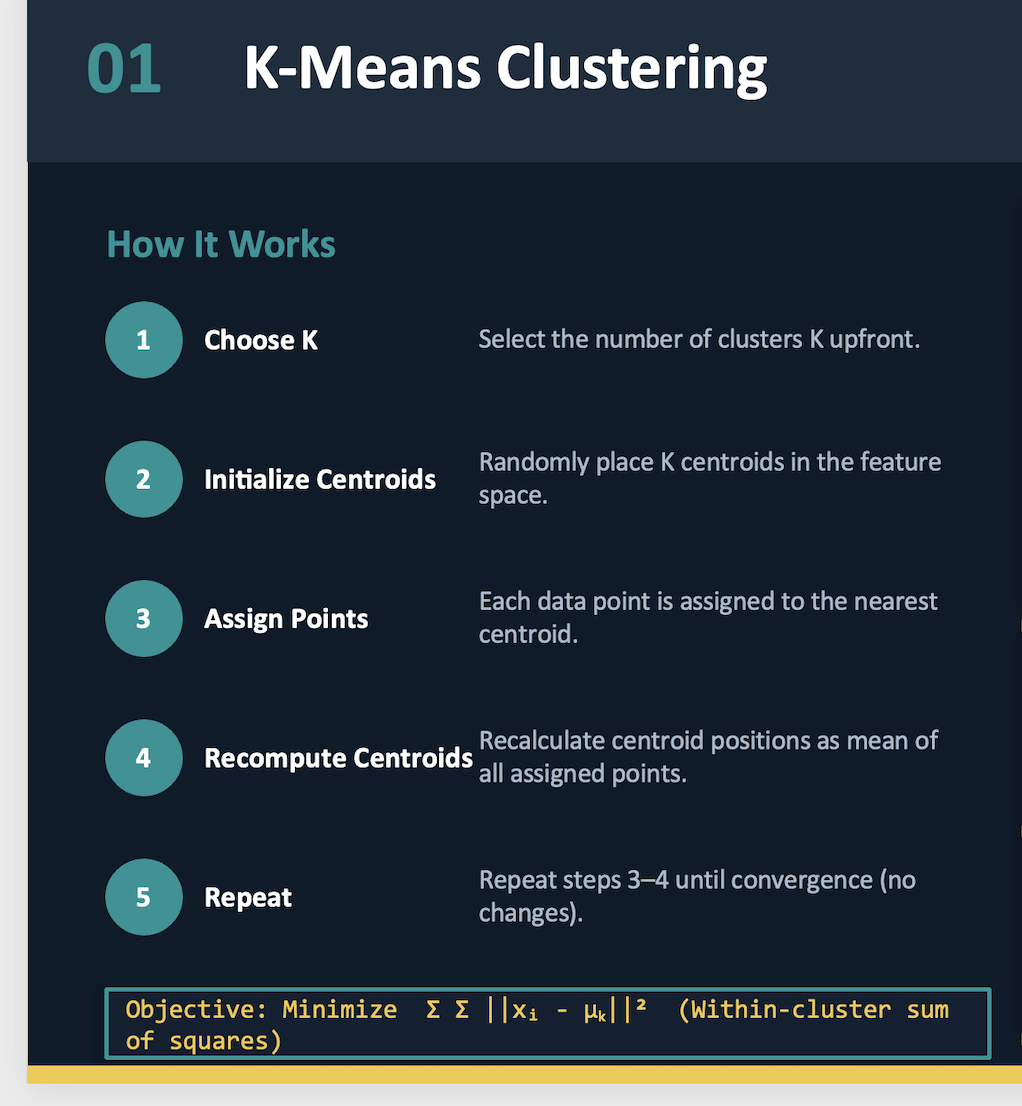

**Euclidean Distance Formula**

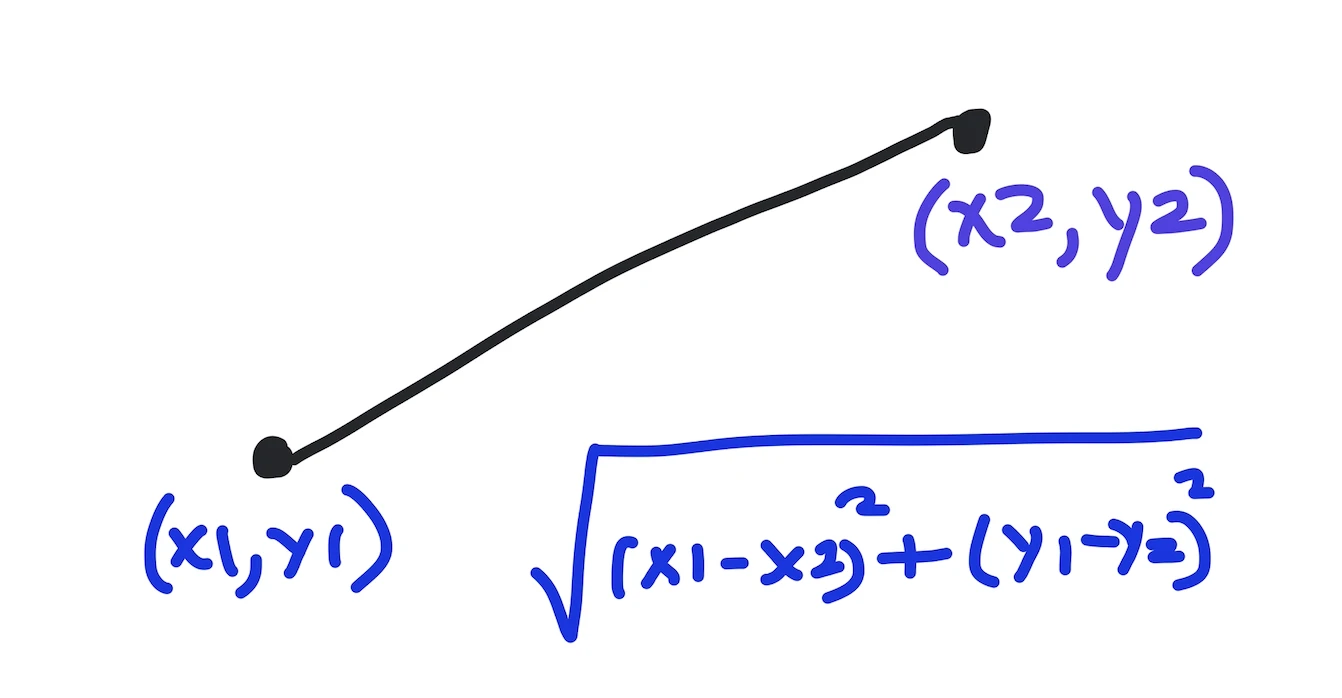



In [ ]:
import pandas as pd                  # For tabular data handling
import matplotlib.pyplot as plt      # For plotting graphs
from sklearn.datasets import load_iris  # To load the Iris dataset
from sklearn.cluster import KMeans       # K-Means clustering algorithm
from sklearn.preprocessing import StandardScaler  # To scale features
from sklearn.metrics import silhouette_score

In [ ]:
iris = load_iris()     # Load the dataset
X = iris.data          # Features (sepal length, sepal width, petal length, petal width)
y = iris.target        # Actual species (0, 1, 2) – used only for comparison

In [ ]:
X

array([[5.1, 3.5, 1.4, 0.2],
       [4.9, 3. , 1.4, 0.2],
       [4.7, 3.2, 1.3, 0.2],
       [4.6, 3.1, 1.5, 0.2],
       [5. , 3.6, 1.4, 0.2],
       [5.4, 3.9, 1.7, 0.4],
       [4.6, 3.4, 1.4, 0.3],
       [5. , 3.4, 1.5, 0.2],
       [4.4, 2.9, 1.4, 0.2],
       [4.9, 3.1, 1.5, 0.1],
       [5.4, 3.7, 1.5, 0.2],
       [4.8, 3.4, 1.6, 0.2],
       [4.8, 3. , 1.4, 0.1],
       [4.3, 3. , 1.1, 0.1],
       [5.8, 4. , 1.2, 0.2],
       [5.7, 4.4, 1.5, 0.4],
       [5.4, 3.9, 1.3, 0.4],
       [5.1, 3.5, 1.4, 0.3],
       [5.7, 3.8, 1.7, 0.3],
       [5.1, 3.8, 1.5, 0.3],
       [5.4, 3.4, 1.7, 0.2],
       [5.1, 3.7, 1.5, 0.4],
       [4.6, 3.6, 1. , 0.2],
       [5.1, 3.3, 1.7, 0.5],
       [4.8, 3.4, 1.9, 0.2],
       [5. , 3. , 1.6, 0.2],
       [5. , 3.4, 1.6, 0.4],
       [5.2, 3.5, 1.5, 0.2],
       [5.2, 3.4, 1.4, 0.2],
       [4.7, 3.2, 1.6, 0.2],
       [4.8, 3.1, 1.6, 0.2],
       [5.4, 3.4, 1.5, 0.4],
       [5.2, 4.1, 1.5, 0.1],
       [5.5, 4.2, 1.4, 0.2],
       [4.9, 3

In [ ]:
y

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2])

In [ ]:
# Feature Scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

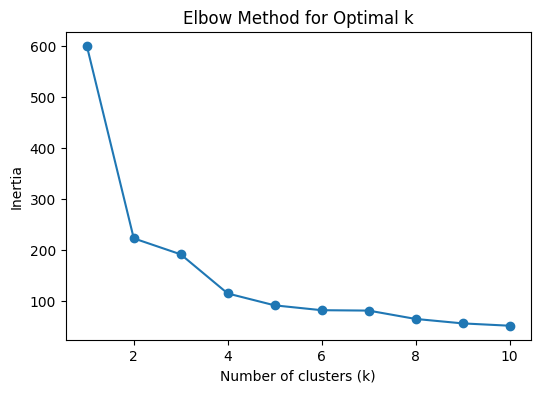

In [ ]:
inertia = []
for k in range(1, 11):                # Test k from 1 to 10
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)   # Inertia = sum of squared distances to cluster centers

# Plot the elbow curve
plt.figure(figsize=(6, 4))
plt.plot(range(1, 11), inertia, marker='o')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method for Optimal k')
plt.show()

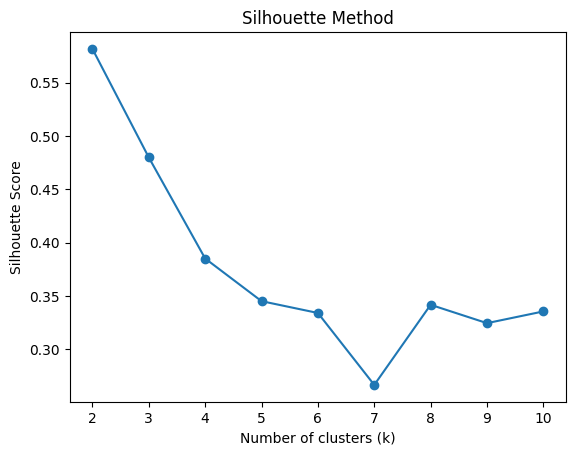

In [ ]:
# kmeans = KMeans(n_clusters=3, random_state=42)  # k=3 because we know there are 3 species
# kmeans.fit(X_scaled)
# labels = kmeans.labels_  # Predicted cluster labels for each sample

silhouette_scores = []

for k in range(2, 11):  # starts from 2
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels_temp = kmeans.fit_predict(X_scaled)

    score = silhouette_score(X_scaled, labels_temp)
    silhouette_scores.append(score)

# Plot Silhouette Scores
plt.figure()
plt.plot(range(2, 11), silhouette_scores, marker='o')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Method')
plt.show()

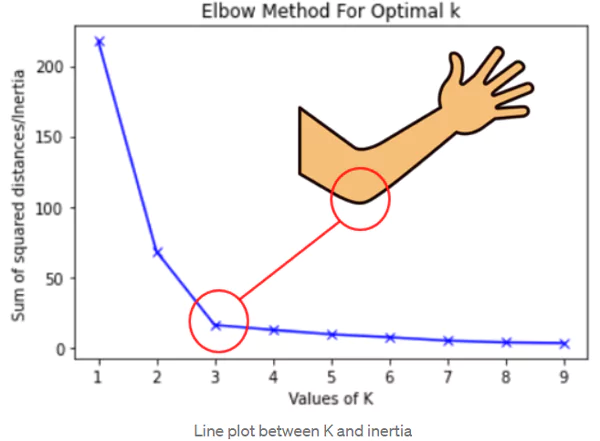

In [ ]:
# Best K from silhouette
best_k = range(2, 11)[silhouette_scores.index(max(silhouette_scores))]
print("Best K (Silhouette):", best_k)

Best K (Silhouette): 2


In [ ]:
#  Train Final K-Means Model
kmeans = KMeans(n_clusters=3, random_state=42)
kmeans.fit(X_scaled)

labels = kmeans.labels_
centroids = kmeans.cluster_centers_


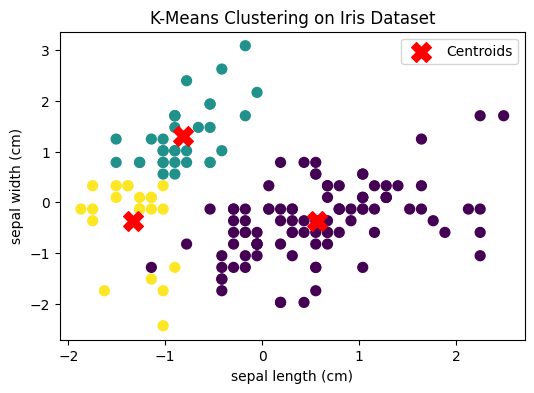

In [ ]:
plt.figure(figsize=(6, 4))
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=labels, cmap='viridis', s=50)  # Data points
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1],
            c='red', marker='X', s=200, label='Centroids')  # Cluster centers
plt.xlabel(iris.feature_names[0])
plt.ylabel(iris.feature_names[1])
plt.title('K-Means Clustering on Iris Dataset')
plt.legend()
plt.show()

In [ ]:
# df = pd.DataFrame({
#     'Actual Species': y,
#     'Cluster Label': labels
# })
# print(df)

In [ ]:
#  Predict New Data
import numpy as np

print("\nEnter new Iris flower features:")

sepal_length = float(input("Sepal length (cm): "))
sepal_width = float(input("Sepal width (cm): "))
petal_length = float(input("Petal length (cm): "))
petal_width = float(input("Petal width (cm): "))

new_sample = np.array([[sepal_length, sepal_width, petal_length, petal_width]])

# Scale input
new_sample_scaled = scaler.transform(new_sample)

# Predict cluster
cluster = kmeans.predict(new_sample_scaled)

print("The new sample belongs to cluster:", cluster[0])


Enter new Iris flower features:


KeyboardInterrupt: Interrupted by user

**Hierarchical Clustering**

Hierarchical clustering is an unsupervised machine learning algorithm that groups similar data points into a tree-like structure called a dendrogram.

**Types of Hierarchical Clustering**
Now we understand the basics of hierarchical clustering. There are two main types of hierarchical clustering.

**Agglomerative Clustering**\
**Divisive clustering**

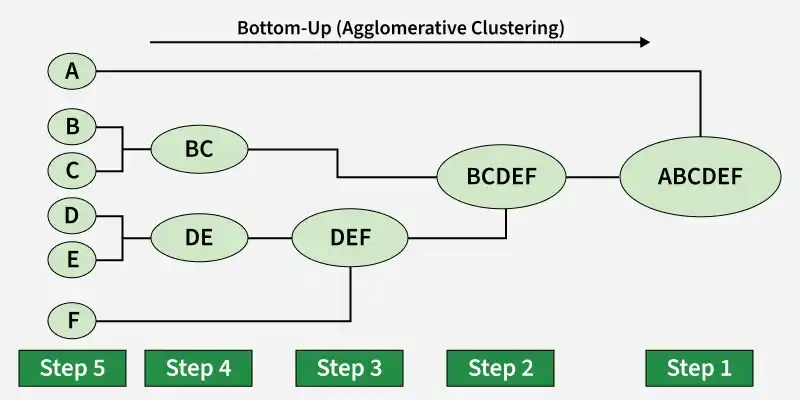

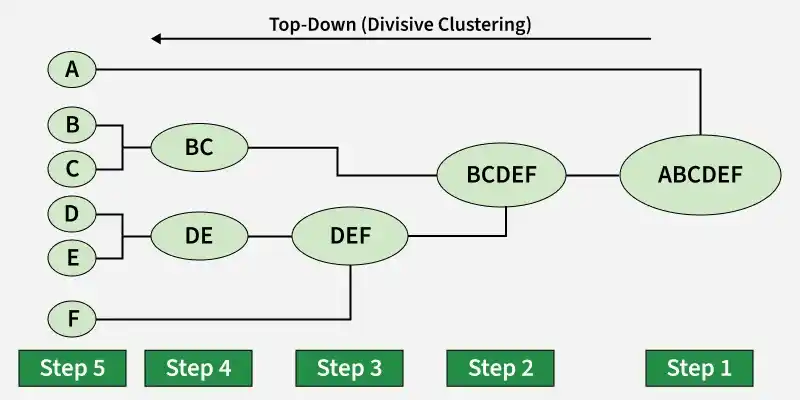

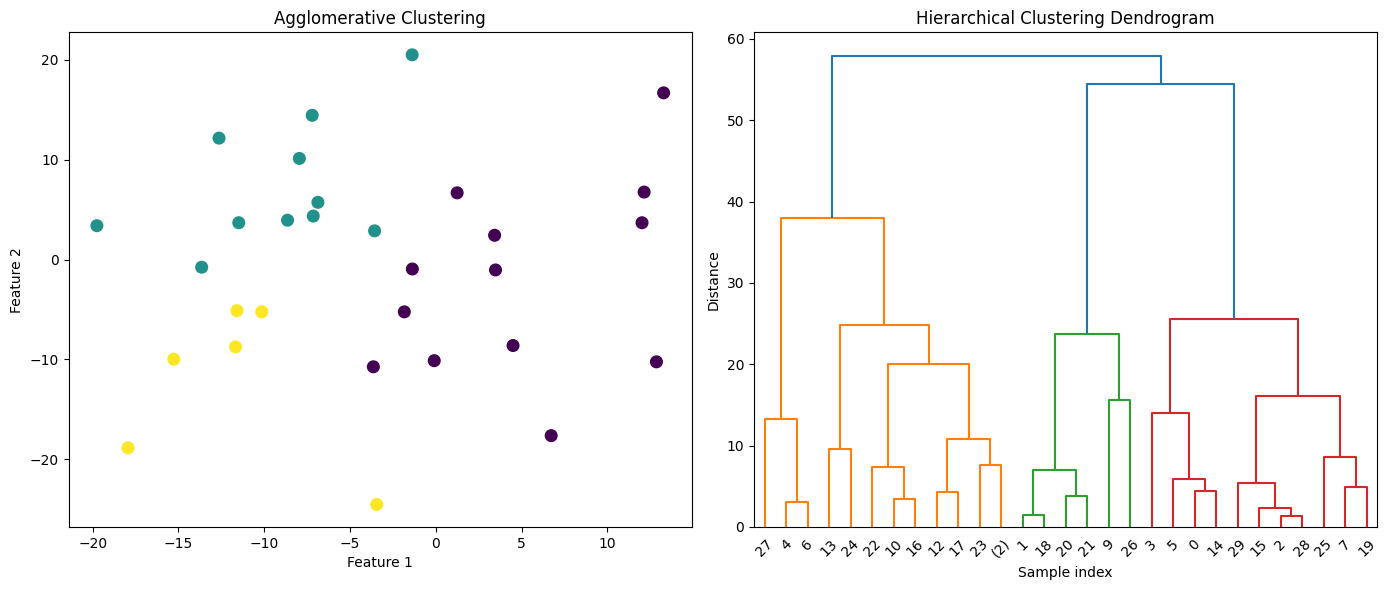

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram
from sklearn.datasets import make_blobs

X, _ = make_blobs(n_samples=30, centers=3, cluster_std=10, random_state=42)

clustering = AgglomerativeClustering(n_clusters=3)
labels = clustering.fit_predict(X)

agg = AgglomerativeClustering(distance_threshold=0, n_clusters=None)
agg.fit(X)


def plot_dendrogram(model, **kwargs):
    counts = np.zeros(model.children_.shape[0])
    n_samples = len(model.labels_)

    for i, merge in enumerate(model.children_):
        current_count = 0
        for child_idx in merge:
            if child_idx < n_samples:
                current_count += 1
            else:
                current_count += counts[child_idx - n_samples]
        counts[i] = current_count

    linkage_matrix = np.column_stack(
        [model.children_, model.distances_, counts]).astype(float)
    dendrogram(linkage_matrix, **kwargs)


fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

ax1.scatter(X[:, 0], X[:, 1], c=labels, cmap='viridis', s=70)
ax1.set_title("Agglomerative Clustering")
ax1.set_xlabel("Feature 1")
ax1.set_ylabel("Feature 2")

plt.sca(ax2)
plot_dendrogram(agg, truncate_mode='level', p=5)
plt.title("Hierarchical Clustering Dendrogram")
plt.xlabel("Sample index")
plt.ylabel("Distance")

plt.tight_layout()
plt.show()

**Computing Distance Matrix**

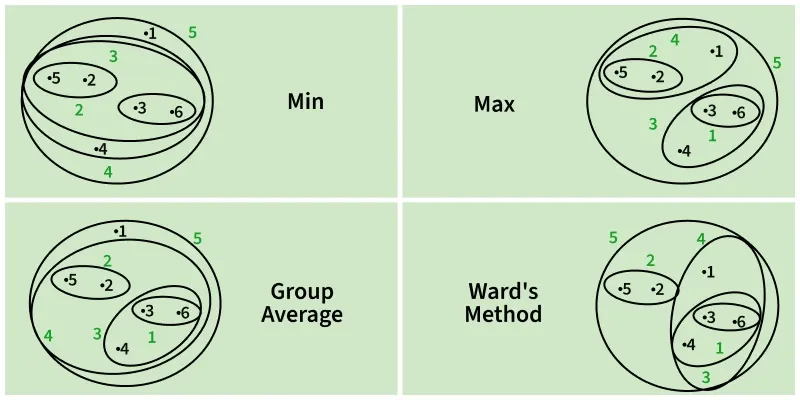

**Computing Distance Matrix**

While merging two clusters we check the distance between two every pair of clusters and merge the pair with the least distance/most similarity. But the question is how is that distance determined. There are different ways of defining Inter Cluster distance/similarity. Some of them are:

**Min Distance:** Find the minimum distance between any two points of the cluster.

**Max Distance:** Find the maximum distance between any two points of the cluster.

**Group Average:** Find the average distance between every two points of the clusters.

**Ward's Method:** The similarity of two clusters is based on the increase in squared error when two clusters are merged.

**DBSCAN Clustering**

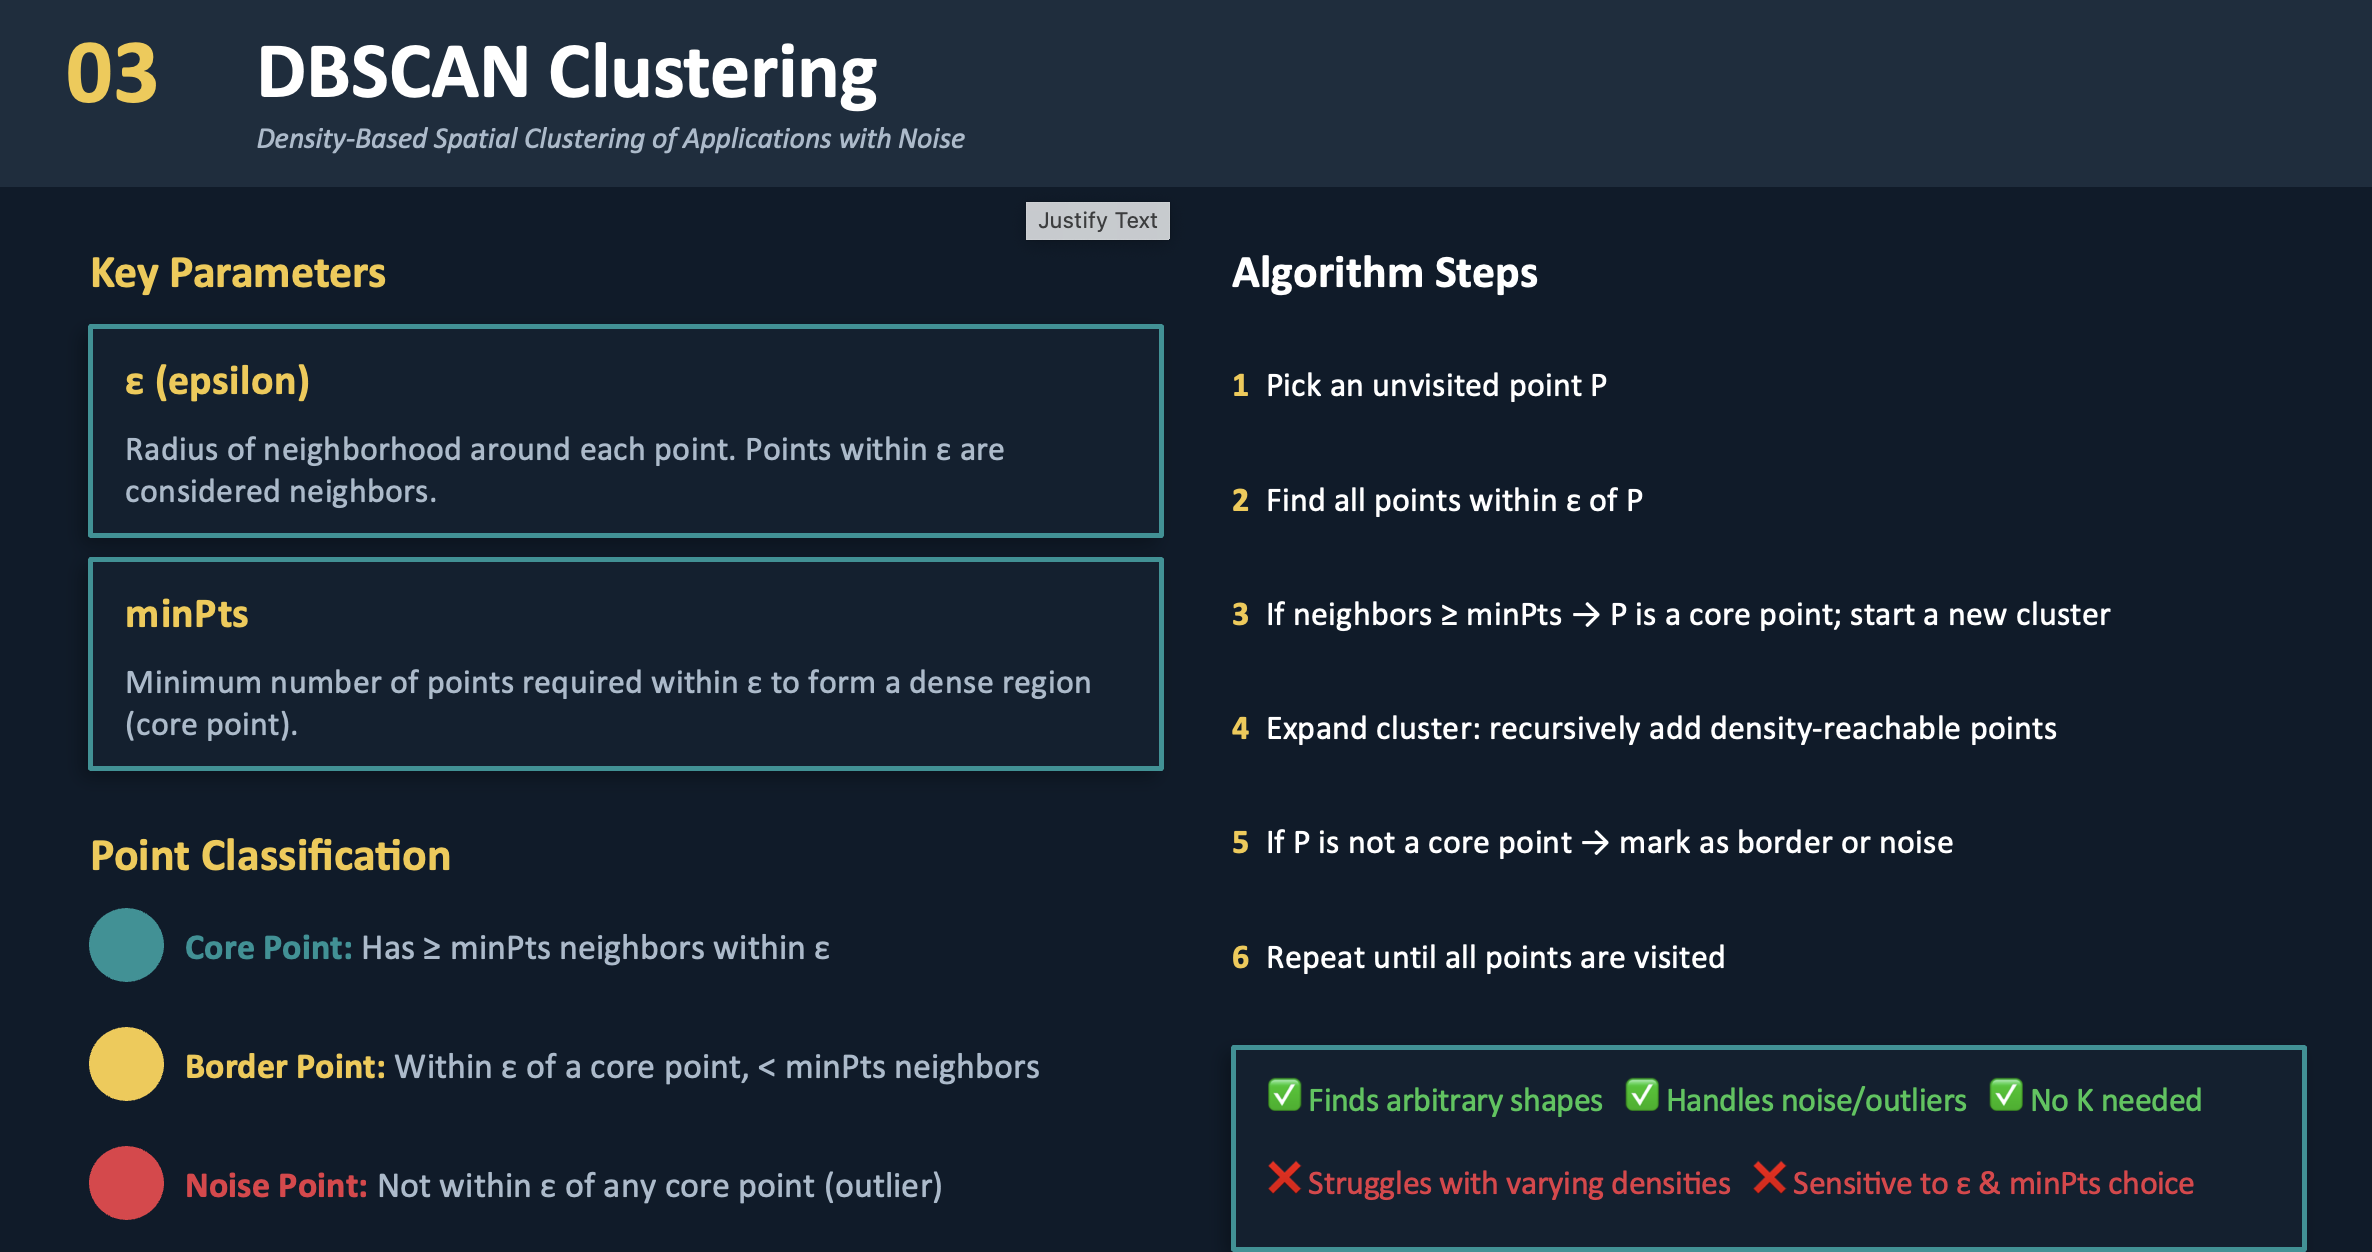

**DBSCAN is a density-based clustering algorithm** that groups data points that are closely packed together and marks outliers as noise based on their density in the feature space. It identifies clusters as dense regions in the data space separated by areas of lower density.

**Find dense groups, ignore lonely points**

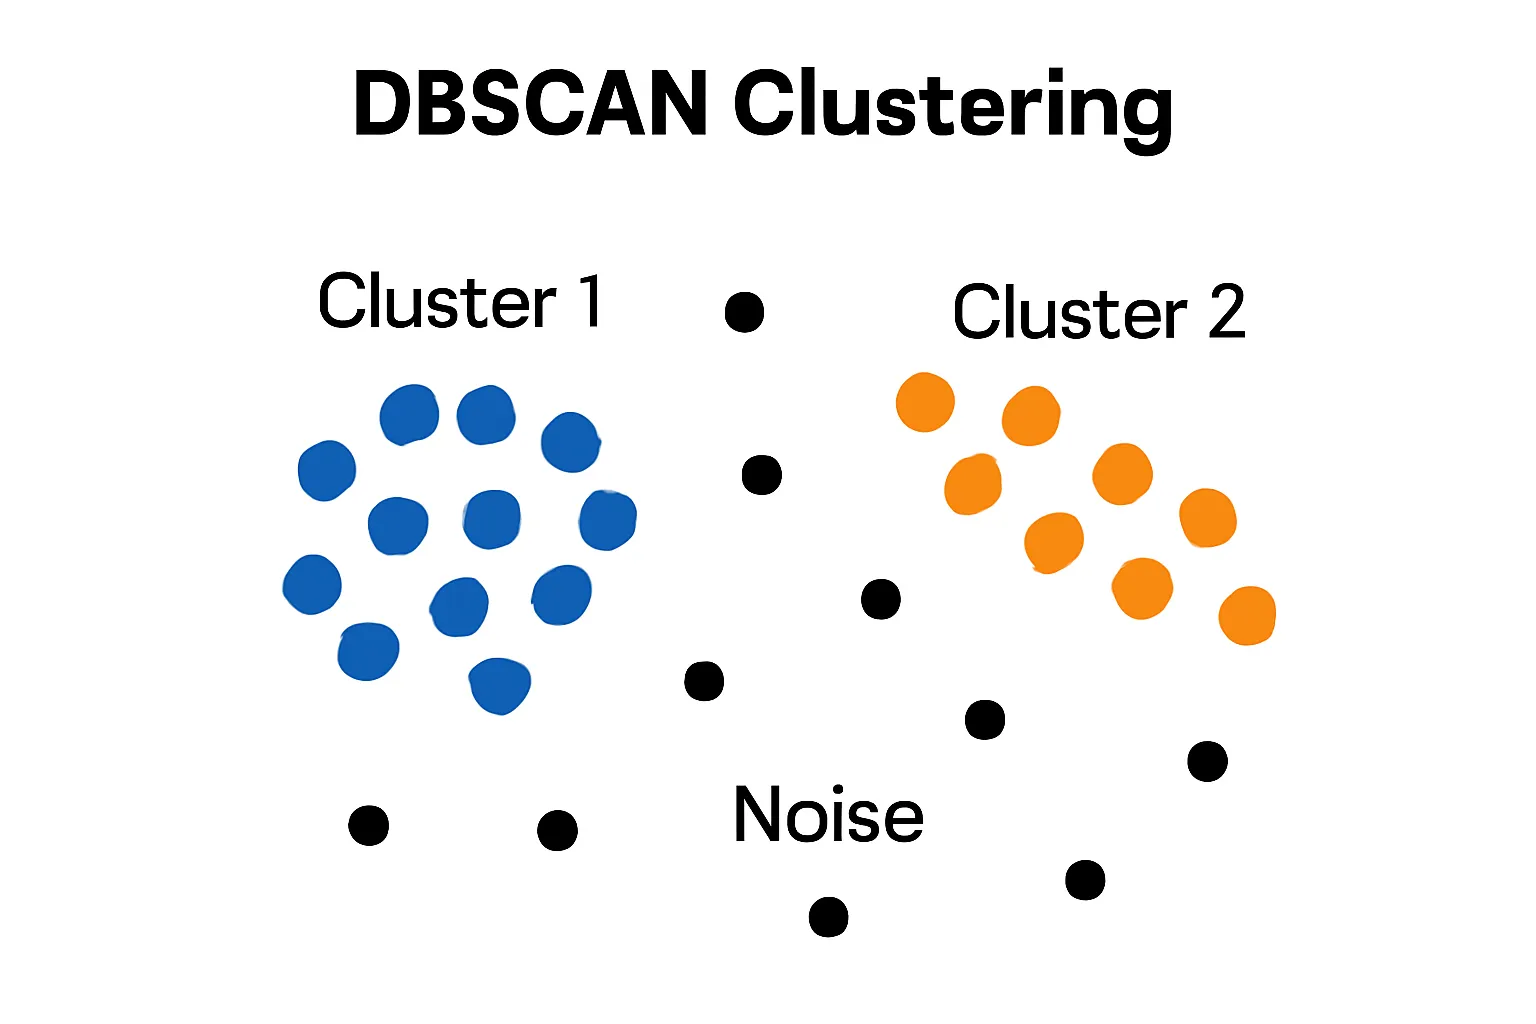

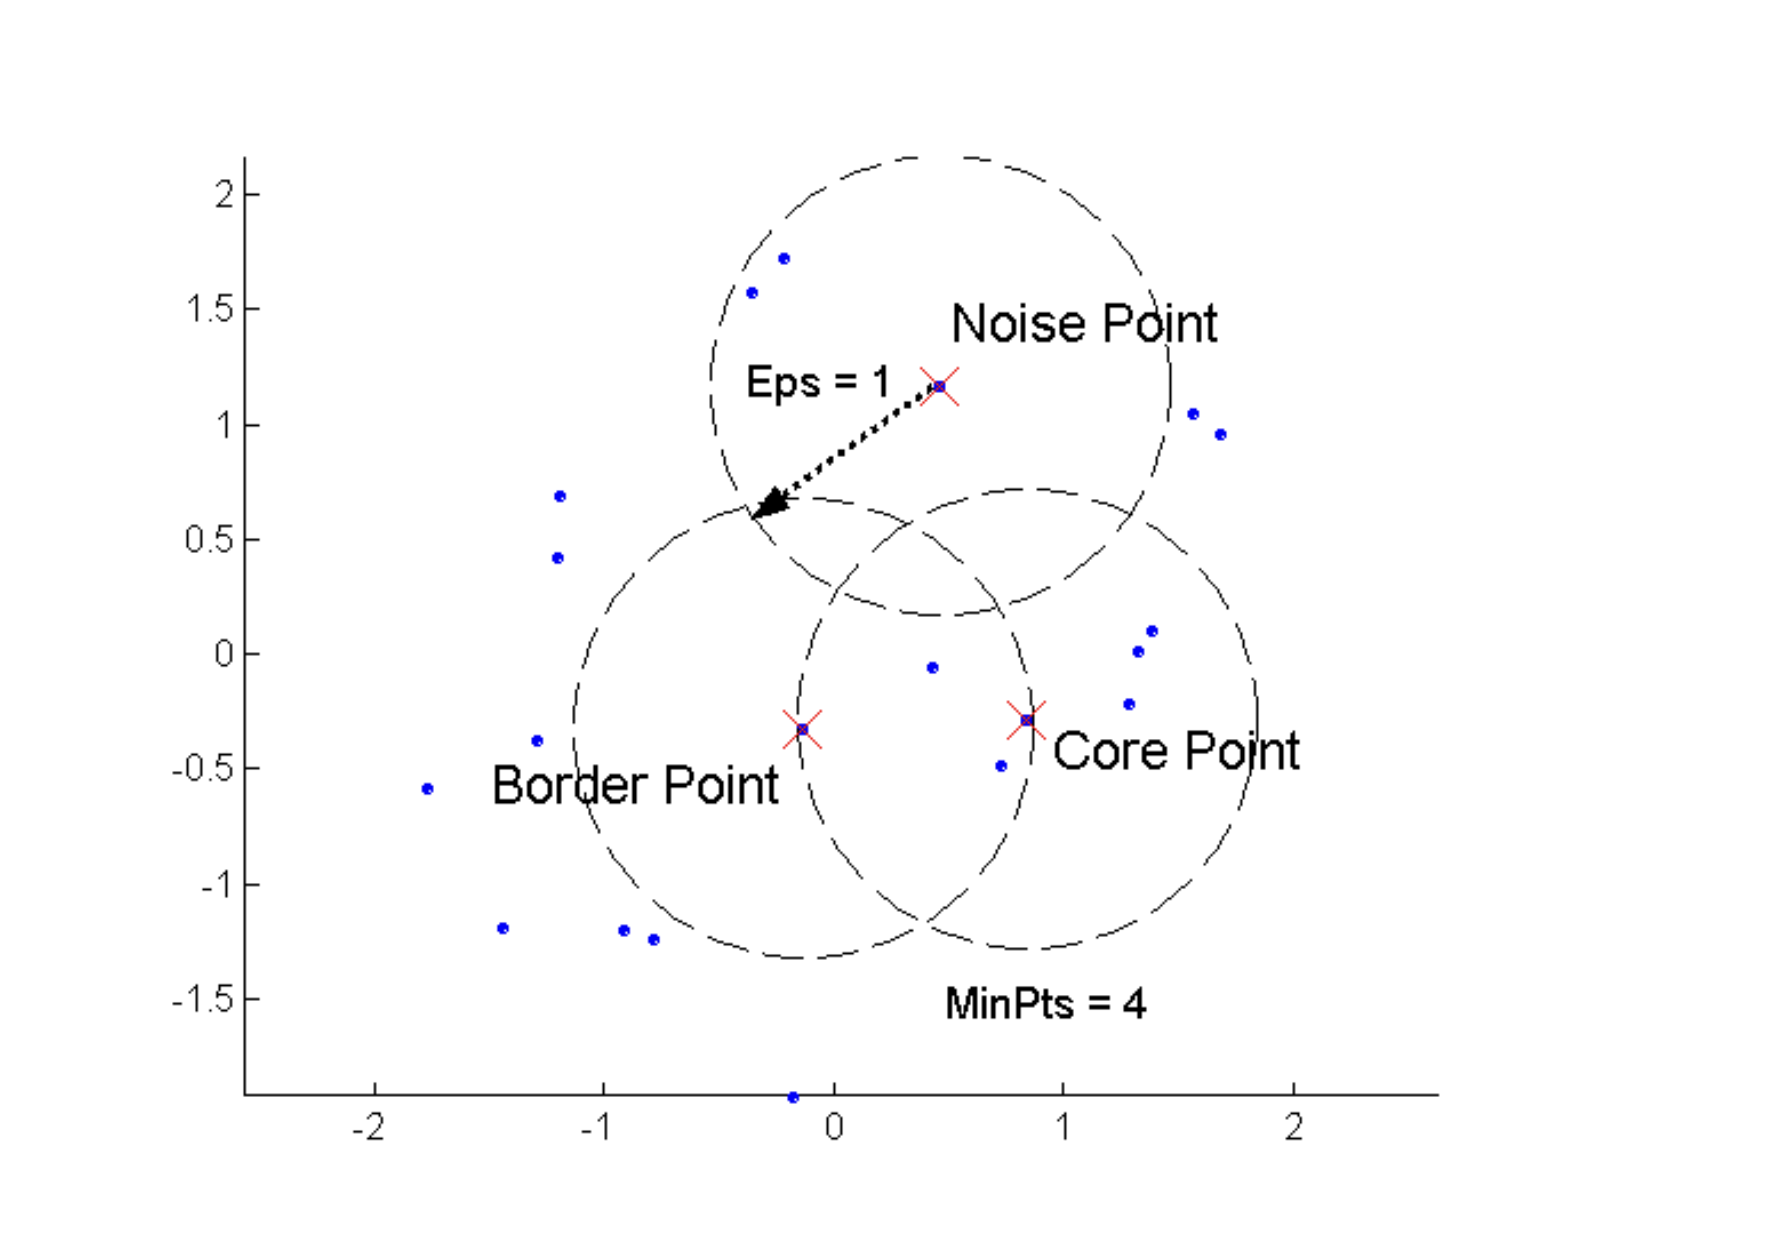

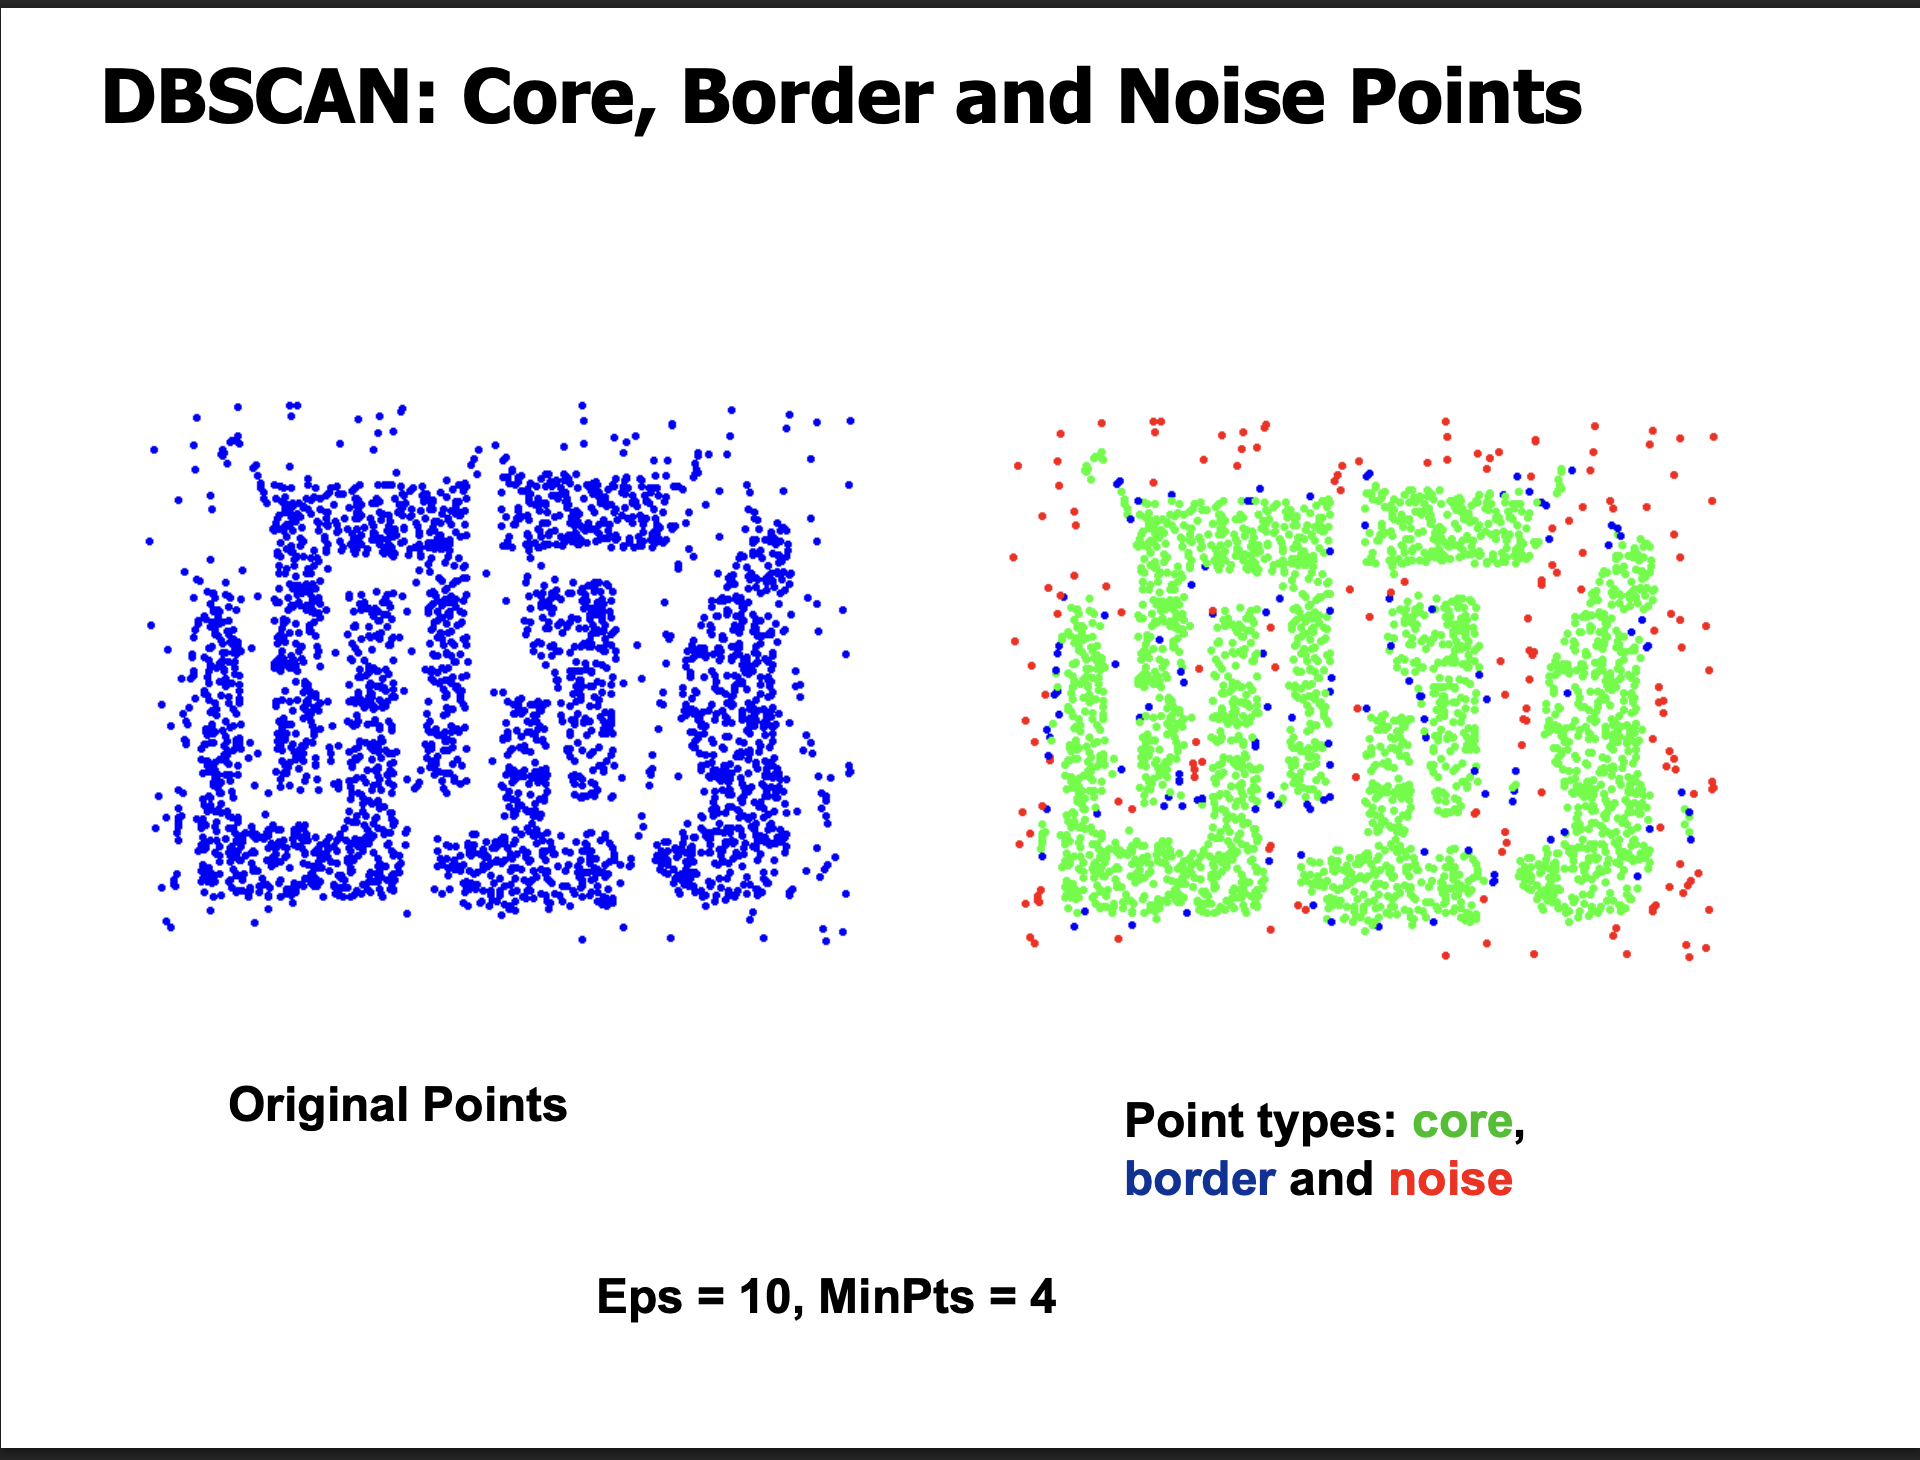

Unique labels: [-1  0  1]
Points per cluster: Counter({np.int64(0): 149, np.int64(1): 149, np.int64(-1): 2})


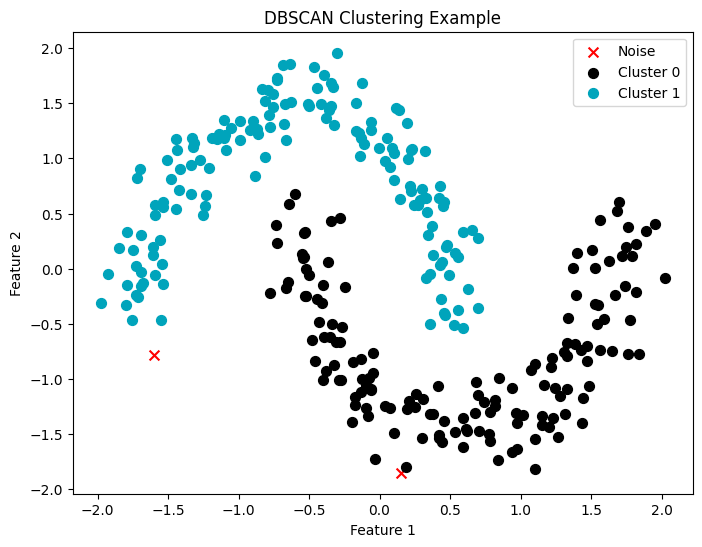

In [ ]:
# Step 1: Import libraries
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import DBSCAN
from sklearn.datasets import make_moons
from sklearn.preprocessing import StandardScaler

# Step 2: Create sample data
# Using make_moons to get non-linear clusters (good for DBSCAN demonstration)
X, _ = make_moons(n_samples=300, noise=0.1, random_state=42)

# Step 3: Scale data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Step 4: Create DBSCAN model
# eps = radius, min_samples = minimum points to form a cluster
dbscan = DBSCAN(eps=0.3, min_samples=5)

# Step 5: Fit model
dbscan.fit(X_scaled)

# Step 6: Get cluster labels
labels = dbscan.labels_
# -1 label is noise
print("Unique labels:", np.unique(labels))

# Step 7: Count points in each cluster
from collections import Counter
print("Points per cluster:", Counter(labels))

# Step 8: Visualize clusters
plt.figure(figsize=(8,6))

# Loop through each cluster
for label in np.unique(labels):
    if label == -1:
        # Noise points in red
        color = 'red'
        marker = 'x'
        size = 50
        label_name = 'Noise'
    else:
        # Cluster points
        color = plt.cm.nipy_spectral(label / len(np.unique(labels)))
        marker = 'o'
        size = 50
        label_name = f'Cluster {label}'

    plt.scatter(X_scaled[labels==label, 0], X_scaled[labels==label, 1],
                c=[color], marker=marker, s=size, label=label_name)

plt.title("DBSCAN Clustering Example")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.legend()
plt.show()